Max location: (np.int64(92), np.int64(88))


<Figure size 640x480 with 0 Axes>

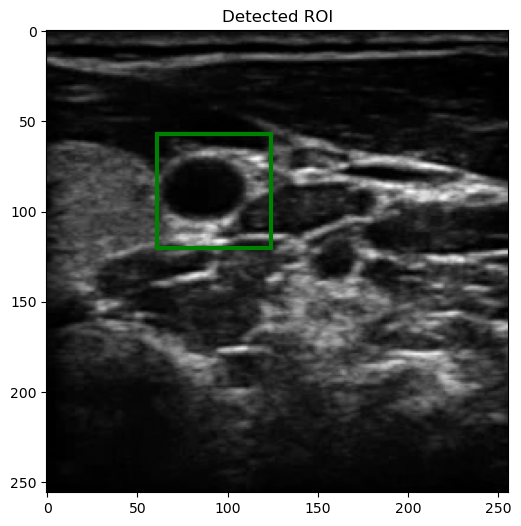

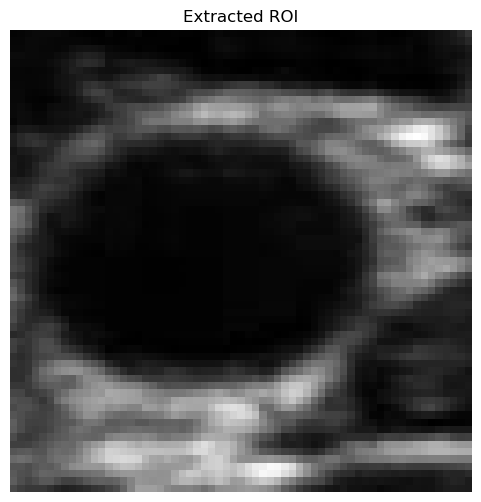


Applying K-Means Clustering...


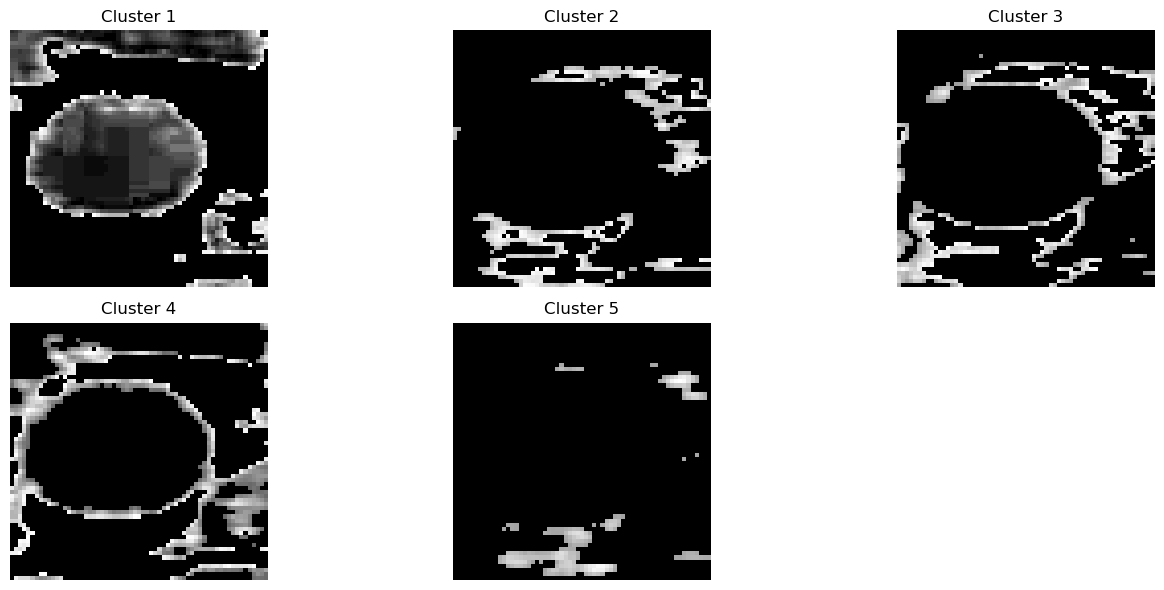


Select cluster (1-5):  1


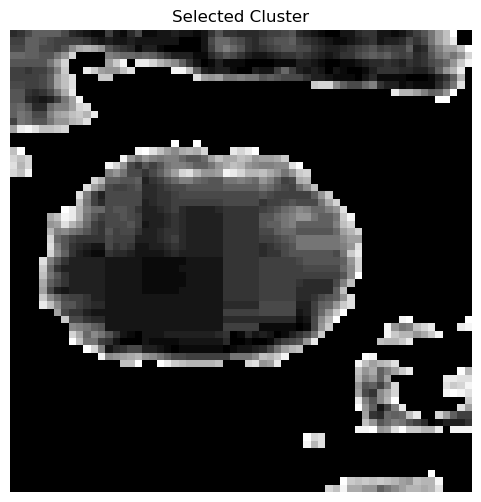


Draw ROI and press ENTER


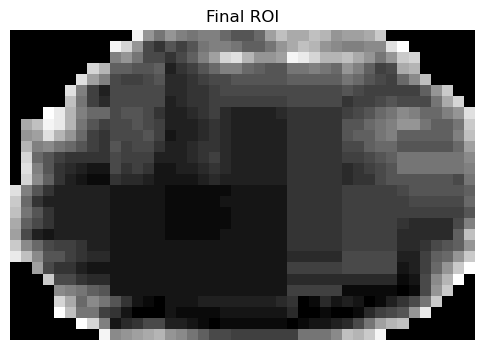


----------------------------
Texture Features : Cluster 1 ROI
----------------------------
Contrast     : 16.349303135888505
Correlation  : 0.6996291669663558
Energy       : 0.19568985455537433
Homogeneity  : 0.6500886915792218
Min pixel: 0
Max pixel: 24

----------------------------
Plaque Quantification
----------------------------
Threshold Used : 5
Plaque Pixels  : 635
Total Pixels   : 1176
Plaque %       : 54.0


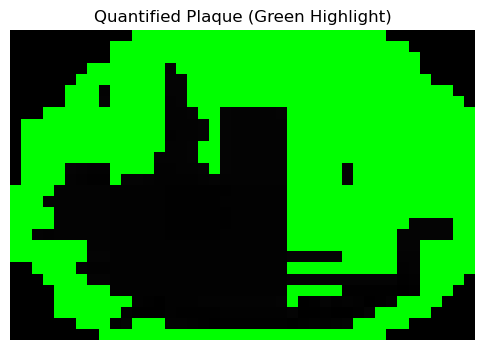

In [22]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import numpy as np
import math
import scipy.ndimage as fi
import os

from sklearn.cluster import KMeans
from skimage.feature import graycomatrix, graycoprops

#---------------------------------------------------------------------------

RADIUS, SPREAD = 4, 4

MASK_SIZE = 3
mask = np.array([-1] * MASK_SIZE + [1] * MASK_SIZE) / MASK_SIZE

plt.set_cmap('gray')

# -------------------------------------------------------------------------
path = r'C:\Users\surya\OneDrive\Desktop\Mini Project - 6th Sem'
file = 'm4.png'


# -----------------------------------------------------------------------------

def showImage(im, title=None):

    plt.figure(figsize=(6,6))
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


#-------------------------------------------------------------------

def templateMatching(img, tpl):

    ims = img.shape
    ts = tpl.shape
    ts = ts[0]//2, ts[1]//2

    corIm = np.zeros(ims, int)

    for r in range(ts[0], ims[0]-ts[0]):
        for c in range(ts[1], ims[1]-ts[1]):

            subim = img[r-ts[0]:r+ts[0]+1,
                        c-ts[1]:c+ts[1]+1]

            corr = np.sum(subim * tpl)
            corIm[r, c] = corr

    return corIm


#----------------------------------------------------------------------------

def findMaxRegion(cimg):

    h, w = cimg.shape

    max_val = cimg.max()
    maxloc = np.argmax(cimg)

    row = maxloc // w
    col = maxloc - row * w

    return ((col, row), max_val)


#----------------------------------------------------------------------------

def showResult(img, tpl, loc):

    tpl -= np.min(tpl)
    tpl = (tpl * 255) // np.max(tpl)

    h, w = tpl.shape

    x = loc[0] - w//2
    y = loc[1] - h//2

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(img)

    ax.add_patch(Rectangle((x,y),
                           w,
                           h,
                           fc='none',
                           ec='g',
                           lw=3))

    plt.title("Detected ROI")
    plt.show()

    return x,y,w,h


#--------------------------------------------------------------------------------

def LoGDisc(radedge, sigma=3):

    gsize = sigma * 3
    rad = int(np.ceil(radedge + 4*sigma))

    circularEdge = np.ones((2 * rad + 1,
                            2 * rad + 1), float)

    gaussian = np.zeros((2 * gsize + 1,
                         2 * gsize + 1), float)

    gaussian[gsize, gsize] = 1
    gaussian = fi.gaussian_filter(gaussian, sigma)

    LoGTpl = cv2.Laplacian(gaussian,
                           cv2.CV_64F)

    for ri in range(-rad, rad+1):
        for ci in range(-rad, rad+1):

            r2 = math.sqrt(ri*ri + ci*ci)

            if r2 > radedge:
                circularEdge[ri+rad,
                             ci+rad] = 0

    template = cv2.filter2D(circularEdge,
                            -1,
                            LoGTpl)

    return template


#--------------------------------------------------------------------

def readImage(file):

    img = cv2.imread(file, 0)
    img = cv2.resize(img, (256,256))

    return img


#--------------------------------------------------------------------------------

def findMaxCorrelation(img, rho, sigma):

    cuRMAX = 0

    for s in range(-12,12):

        LoGTpl = LoGDisc(rho+s, sigma)

        CorImg = templateMatching(img, LoGTpl)

        loc, max_val = findMaxRegion(CorImg)

        if max_val > cuRMAX:

            cuRMAX = max_val
            maxloc = loc
            maxs = s
            cimg = CorImg

    return cimg, maxloc, maxs


# ============================================================
# Texture Analysis
# ============================================================

def texture_analysis(img, name):

    img = img.astype(np.uint8)

    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    print("\n----------------------------")
    print(f"Texture Features : {name}")
    print("----------------------------")
    print("Contrast     :", contrast)
    print("Correlation  :", correlation)
    print("Energy       :", energy)
    print("Homogeneity  :", homogeneity)


# ============================================================
# Plaque Quantification + Adaptive Green Highlight
# ============================================================

def quantify_plaque(roi):

    print("Min pixel:", roi.min())
    print("Max pixel:", roi.max())

    # Adaptive threshold
    threshold = int(np.mean(roi))

    mask = roi >= threshold

    non_black_pixels = np.count_nonzero(mask)
    total_pixels = roi.size

    plaque_percent = (non_black_pixels / total_pixels) * 100


    print("\n----------------------------")
    print("Plaque Quantification")
    print("----------------------------")
    print("Threshold Used :", threshold)
    print("Plaque Pixels  :", non_black_pixels)
    print("Total Pixels   :", total_pixels)
    print("Plaque %       :", round(plaque_percent,2))


    colored = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)

    colored[mask] = [0,255,0]


    plt.figure(figsize=(6,6))
    plt.imshow(colored)
    plt.title("Quantified Plaque (Green Highlight)")
    plt.axis('off')
    plt.show()
# ============================================================
# KMEANS + ROI SELECTION
# ============================================================

def kmeans_segmentation(roi):

    print("\nApplying K-Means Clustering...")

    pixel_values = roi.reshape((-1,1))
    pixel_values = np.float32(pixel_values)

    k = 5

    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    labels = kmeans.fit_predict(pixel_values)
    labels_2d = labels.reshape(roi.shape)

    clusters = []

    plt.figure(figsize=(14,6))

    for i in range(k):

        cluster = np.zeros_like(roi)
        cluster[labels_2d == i] = roi[labels_2d == i]
        clusters.append(cluster)

        plt.subplot(2,3,i+1)
        plt.imshow(cluster, cmap='gray')
        plt.title(f"Cluster {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


    cluster_id = int(input("\nSelect cluster (1-5): "))

    selected_cluster = clusters[cluster_id-1]

    showImage(selected_cluster,"Selected Cluster")


    print("\nDraw ROI and press ENTER")

    scale = 3

    large_img = cv2.resize(
        selected_cluster,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )

    cv2.namedWindow("Select ROI", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Select ROI", 1000, 800)

    roi_select = cv2.selectROI(
        "Select ROI",
        large_img,
        showCrosshair=True
    )

    cv2.destroyAllWindows()

    x, y, w, h = roi_select

    x = int(x/scale)
    y = int(y/scale)
    w = int(w/scale)
    h = int(h/scale)

    final_roi = selected_cluster[y:y+h, x:x+w]

    showImage(final_roi,"Final ROI")


    texture_analysis(
        final_roi,
        f"Cluster {cluster_id} ROI"
    )


    quantify_plaque(final_roi)


#----------------------------------------------------------------------------

def main():

    rho, sigma = RADIUS, SPREAD

    img = readImage(os.path.join(path, file))

    cimg, maxloc, maxs = findMaxCorrelation(
                         img,
                         rho,
                         sigma)

    print("Max location:", maxloc)

    LoGTpl = LoGDisc(rho+maxs, sigma)

    x,y,w,h = showResult(
        img,
        LoGTpl,
        maxloc
    )

    roi = img[y:y+h, x:x+w]

    showImage(roi, "Extracted ROI")

    kmeans_segmentation(roi)


#----------------------------------------------------------------------------

main()